# Label distribution in main caption and alt captions

This notebook loads label files from the current `labels` folder, extracts `main_caption` and `alt_captions`, and visualizes the label frequency distribution for both caption types.

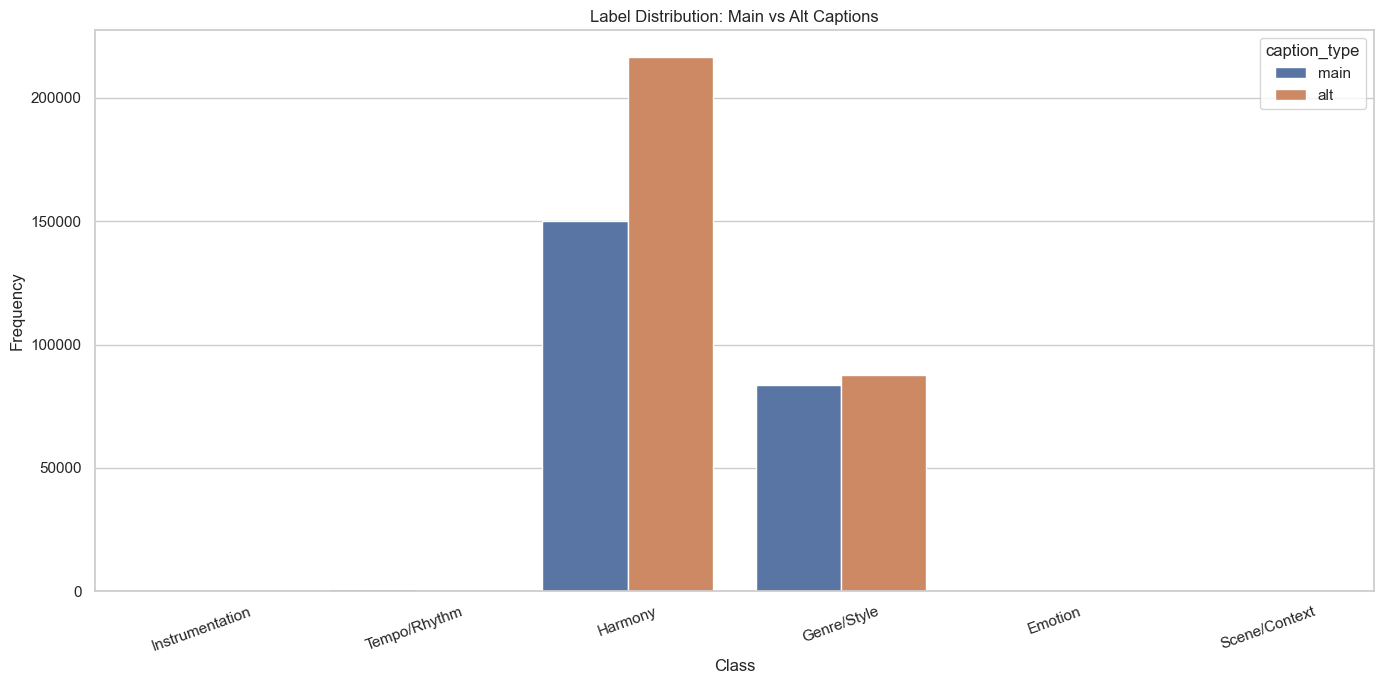

In [11]:
from collections import Counter
import json
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set(style="whitegrid")

# load files
with open("main_caption_classes.json", "r") as f:
    main_caption_classes = json.load(f)

with open("alt_caption_classes.json", "r") as f:
    alt_caption_classes = json.load(f)

# flatten multi-label structure
def flatten_labels(caption_classes):
    flat = []
    for caption in caption_classes:
        for sentence_labels in caption:
            if isinstance(sentence_labels, list):
                flat.extend(sentence_labels)
            else:
                flat.append(sentence_labels)
    return flat

main_labels = flatten_labels(main_caption_classes)
alt_labels = flatten_labels(alt_caption_classes)

# count labels
main_counts = Counter(main_labels)
alt_counts = Counter(alt_labels)

label_names = {
    0: "Instrumentation",
    1: "Tempo/Rhythm",
    2: "Harmony",
    3: "Genre/Style",
    4: "Emotion",
    5: "Scene/Context"
}

# build dataframe
combined = []

for label in range(6):
    combined.append({
        "label": label_names[label],
        "caption_type": "main",
        "count": main_counts.get(label, 0)
    })

    combined.append({
        "label": label_names[label],
        "caption_type": "alt",
        "count": alt_counts.get(label, 0)
    })

combined_df = pd.DataFrame(combined)

# plot
plt.figure(figsize=(14, 7))

sns.barplot(
    data=combined_df,
    x="label",
    y="count",
    hue="caption_type"
)

plt.title("Label Distribution: Main vs Alt Captions")
plt.xlabel("Class")
plt.ylabel("Frequency")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [12]:
import json
from collections import defaultdict
import random

# load original training data
with open("C:\\Users\\Theodore da Cunha\\Desktop\\project\\research\\language_alignment\\data\\MusicBench_train.json", "r", encoding="utf-8") as f:
    train_data = json.load(f)

# load class labels
with open("main_caption_classes.json", "r") as f:
    main_caption_classes = json.load(f)

with open("alt_caption_classes.json", "r") as f:
    alt_caption_classes = json.load(f)

# split captions into sentences
split_main_captions = [
    [s.strip() for s in item["main_caption"].split(".") if s.strip()]
    for item in train_data
]

split_alt_captions = [
    [s.strip() for s in item["alt_caption"].split(".") if s.strip()]
    for item in train_data
]

label_names = {
    0: "Instrumentation and timbre",
    1: "Tempo rhythm beat meter",
    2: "Key chords harmony progression",
    3: "Genre style production",
    4: "Emotion mood feeling",
    5: "Scene imagery context"
}

# group sentences by label
main_examples = defaultdict(list)
alt_examples = defaultdict(list)

for caption_sentences, caption_labels in zip(split_main_captions, main_caption_classes):
    for sentence, label in zip(caption_sentences, caption_labels):
        main_examples[label].append(sentence)

for caption_sentences, caption_labels in zip(split_alt_captions, alt_caption_classes):
    for sentence, label in zip(caption_sentences, caption_labels):
        alt_examples[label].append(sentence)

# show random examples
for label in range(6):
    print("=" * 60)
    print(f"LABEL {label}: {label_names[label]}")
    print("\nMAIN CAPTION EXAMPLES:")
    for example in random.sample(main_examples[label], min(10, len(main_examples[label]))):
        print("-", example)

    print("\nALT CAPTION EXAMPLES:")
    for example in random.sample(alt_examples[label], min(10, len(alt_examples[label]))):
        print("-", example)
    print()

LABEL 0: Instrumentation and timbre

MAIN CAPTION EXAMPLES:
- Water droplets can be heard panning out to the right side of the speakers
- The crackling of a fire serves as the constant backdrop as hard objects hit a wooden floor and glass shatters
- A photo is heard being taken in the background
- This song has an ASMR clip with a crackly and fuzzy sound, accompanied by the ambient tone of a room - possibly an air conditioner humming in the background
- This instrumental track in G minor begins with a catchy synth melody and percussion, which pauses to allow for the sound of water splashing in
- This song creates a Latin feel and could potentially be heard loudly while a person cleans their home with the doors and windows open
- A tambourine highlights each beat, adding a layer of rhythmic texture to the music
- There are no words in this song
- Panned to the right side of the speakers you can hear water dripping
- The sound of running water and a person running can be heard, along wit